# NASDAQ Prediction

In [2]:
import yfinance as yf
import pandas as pd
import pandas_datareader.data as web
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns  # for nicer plots
sns.set(style="darkgrid")  # default style

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
import sklearn.metrics
import tensorflow as tf
from tensorflow import keras
from keras import layers, metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Build Dataset

In [3]:
# define dates
target_start = "2020-01-01"
target_end = "2024-12-31" 
fetch_start = "2019-06-01"

# fetch fred data
macro_data = web.DataReader(
    ["FEDFUNDS", "DGS10", "CPIAUCSL", "PPIACO", "M2SL"], 
    "fred", 
    fetch_start, 
    target_end
)

In [4]:
# sanity check
macro_data.head()

,FEDFUNDS,DGS10,CPIAUCSL,PPIACO,M2SL
DATE,,,,,
2019-06-01,2.38,NaN,255.213,200.3,14771.4
2019-06-03,NaN,2.07,NaN,NaN,NaN
2019-06-04,NaN,2.12,NaN,NaN,NaN
2019-06-05,NaN,2.12,NaN,NaN,NaN
2019-06-06,NaN,2.12,NaN,NaN,NaN


In [5]:
# fetch nasdaq data
nasdaq = yf.Ticker("^IXIC")
nasdaq_data = nasdaq.history(start=target_start, end=target_end, interval="1d")

# drop dividends and stock splits (not used for index)
nasdaq_data.drop(columns=['Stock Splits','Dividends'], inplace=True)

# sanity check
nasdaq_data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02 00:00:00-05:00,9039.459961,9093.429688,9010.889648,9092.190430,2862700000
2020-01-03 00:00:00-05:00,8976.429688,9065.759766,8976.429688,9020.769531,2586520000
2020-01-06 00:00:00-05:00,8943.500000,9072.410156,8943.500000,9071.469727,2810450000
2020-01-07 00:00:00-05:00,9076.639648,9091.929688,9042.549805,9068.580078,2381740000
2020-01-08 00:00:00-05:00,9068.030273,9168.889648,9059.379883,9129.240234,2472620000


In [6]:
# make dates match
nasdaq_data.index = nasdaq_data.index.tz_localize(None)

# sanity check
nasdaq_data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,9039.459961,9093.429688,9010.889648,9092.190430,2862700000
2020-01-03,8976.429688,9065.759766,8976.429688,9020.769531,2586520000
2020-01-06,8943.500000,9072.410156,8943.500000,9071.469727,2810450000
2020-01-07,9076.639648,9091.929688,9042.549805,9068.580078,2381740000
2020-01-08,9068.030273,9168.889648,9059.379883,9129.240234,2472620000


# Feature Engineering

In this section we will
- Correct and add the FRED data
- Add a base bonds ticker (find ticker on yfinance)
- NASDAQ and its 125-day moving average (mac d)
- VIX 
- Yield spread: junk bonds vs. investment grade (Isaac checking this one)

In [7]:
macro_data.head()

,FEDFUNDS,DGS10,CPIAUCSL,PPIACO,M2SL
DATE,,,,,
2019-06-01,2.38,NaN,255.213,200.3,14771.4
2019-06-03,NaN,2.07,NaN,NaN,NaN
2019-06-04,NaN,2.12,NaN,NaN,NaN
2019-06-05,NaN,2.12,NaN,NaN,NaN
2019-06-06,NaN,2.12,NaN,NaN,NaN


In [8]:
# add lags to prevent data leakage
macro_data_shifted = macro_data.copy()

# FEDFUNDS is on a monthly release schedule - shift forward ~1 month (shift down 30 rows)
macro_data_shifted['FEDFUNDS'] = macro_data['FEDFUNDS'].shift(30)
# DGS10 releases daily - shift forward one day
macro_data_shifted['DGS10'] = macro_data['DGS10'].shift(1)
# CPIAUCSL is released toward the middle of the next month - shift forward 45 days
macro_data_shifted['CPIAUCSL'] = macro_data['CPIAUCSL'].shift(45)
# PPIACO is released toward the middle of the next month - shift forward 45 days
macro_data_shifted['PPIACO'] = macro_data['PPIACO'].shift(45)
# M2SL is released toward the end of the next month - shift forward 60 days
macro_data_shifted['M2SL'] = macro_data['M2SL'].shift(60)

# fill daily rows with the monthly etc value
macro_data_shifted = macro_data_shifted.ffill()

# sanity check
# # macro_data_shifted.head(1420)

In [9]:
print(macro_data_shifted.loc["2020-01-01":"2020-01-10"])

#print(macro_data_shifted.loc["2021-01-01":"2021-03-15"])

            FEDFUNDS  DGS10  CPIAUCSL  PPIACO     M2SL
DATE                                                  
2020-01-01      1.55   1.92   257.155   198.6  15167.3
2020-01-02      1.55   1.92   257.879   199.0  15167.3
2020-01-03      1.55   1.88   257.879   199.0  15167.3
2020-01-06      1.55   1.80   257.879   199.0  15167.3
2020-01-07      1.55   1.81   257.879   199.0  15167.3
2020-01-08      1.55   1.83   257.879   199.0  15167.3
2020-01-09      1.55   1.87   257.879   199.0  15167.3
2020-01-10      1.55   1.85   257.879   199.0  15167.3


In [10]:
# Add a base bonds ticker 
tlt = yf.Ticker("TLT")
tlt_data = tlt.history(start=target_start, end=target_end, interval="1d")
tlt_data = tlt_data.drop(columns=['Stock Splits', 'Dividends'])
tlt_data.index = tlt_data.index.tz_localize(None)
tlt_data = tlt_data.add_prefix("TLT_")

In [11]:
# VIX
df_vix = yf.Ticker("^VIX").history(start=target_start, end=target_end, interval="1d")
df_vix = df_vix[['Close']].rename(columns={'Close': 'VIX_Close'})
df_vix.index = df_vix.index.tz_localize(None)

In [12]:
# Initialize base data with NASDAQ
data = nasdaq_data.copy()

In [13]:
# Merge all data sources
merge_sources = [
    macro_data_shifted,
    tlt_data,
    df_vix
]

for df in merge_sources:
    data = data.merge(df, left_index=True, right_index=True, how="left")

In [14]:
# NASDAQ and its 125-day moving average (mac d)
# MACD
short_ema = data['Close'].ewm(span=12, adjust=False).mean()
long_ema = data['Close'].ewm(span=26, adjust=False).mean()
macd = short_ema - long_ema
signal = macd.ewm(span=9, adjust=False).mean()
histogram = macd - signal

macd_df = pd.DataFrame({
    'MACD': macd,
    'MACD_Signal': signal,
    'MACD_Hist': histogram
}, index=data.index)

data = data.merge(macd_df, left_index=True, right_index=True, how='left')

# Yield Spread
data['Yield_Spread'] = data['DGS10'] - data['FEDFUNDS']

In [15]:
# Sanity check
data.head()

,Open,High,Low,Close,Volume,FEDFUNDS,DGS10,CPIAUCSL,PPIACO,M2SL,...,TLT_High,TLT_Low,TLT_Close,TLT_Volume,TLT_Capital Gains,VIX_Close,MACD,MACD_Signal,MACD_Hist,Yield_Spread
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,9039.459961,9093.429688,9010.889648,9092.190430,2862700000,1.55,1.92,257.879,199.0,15167.3,...,119.799944,119.050812,119.346977,11034100,0.0,12.47,0.000000,0.000000,0.000000,0.37
2020-01-03,8976.429688,9065.759766,8976.429688,9020.769531,2586520000,1.55,1.88,257.879,199.0,15167.3,...,121.219787,120.104803,121.184937,12366000,0.0,14.02,-5.697394,-1.139479,-4.557915,0.33
2020-01-06,8943.500000,9072.410156,8943.500000,9071.469727,2810450000,1.55,1.80,257.879,199.0,15167.3,...,121.698924,120.340024,120.496826,11369800,0.0,13.85,-6.051776,-2.121938,-3.929838,0.25
2020-01-07,9076.639648,9091.929688,9042.549805,9068.580078,2381740000,1.55,1.81,257.879,199.0,15167.3,...,120.618782,119.895782,119.904488,8381200,0.0,13.79,-6.490973,-2.995745,-3.495228,0.26
2020-01-08,9068.030273,9168.889648,9059.379883,9129.240234,2472620000,1.55,1.83,257.879,199.0,15167.3,...,120.479378,118.745933,119.111786,10621700,0.0,13.45,-1.922115,-2.781019,0.858904,0.28


In [16]:
data.shape

(1257, 21)

## EDA

In [17]:
# check for NaNs
print(data.isna().sum())

Open                 0
High                 0
Low                  0
Close                0
Volume               0
FEDFUNDS             0
DGS10                0
CPIAUCSL             0
PPIACO               0
M2SL                 0
TLT_Open             0
TLT_High             0
TLT_Low              0
TLT_Close            0
TLT_Volume           0
TLT_Capital Gains    0
VIX_Close            0
MACD                 0
MACD_Signal          0
MACD_Hist            0
Yield_Spread         0
dtype: int64


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1257 entries, 2020-01-02 to 2024-12-30
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Open               1257 non-null   float64
 1   High               1257 non-null   float64
 2   Low                1257 non-null   float64
 3   Close              1257 non-null   float64
 4   Volume             1257 non-null   int64  
 5   FEDFUNDS           1257 non-null   float64
 6   DGS10              1257 non-null   float64
 7   CPIAUCSL           1257 non-null   float64
 8   PPIACO             1257 non-null   float64
 9   M2SL               1257 non-null   float64
 10  TLT_Open           1257 non-null   float64
 11  TLT_High           1257 non-null   float64
 12  TLT_Low            1257 non-null   float64
 13  TLT_Close          1257 non-null   float64
 14  TLT_Volume         1257 non-null   int64  
 15  TLT_Capital Gains  1257 non-null   float64
 16  VIX_Cl

In [19]:
data.describe()

,Open,High,Low,Close,Volume,FEDFUNDS,DGS10,CPIAUCSL,PPIACO,M2SL,...,TLT_High,TLT_Low,TLT_Close,TLT_Volume,TLT_Capital Gains,VIX_Close,MACD,MACD_Signal,MACD_Hist,Yield_Spread
count,1257.000000,1257.000000,1257.000000,1257.000000,1.257000e+03,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000,...,1257.000000,1257.000000,1257.000000,1.257000e+03,1257.0,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000
mean,13396.866510,13496.945254,13287.901373,13398.897142,4.976232e+09,2.390430,2.686070,286.150564,237.433354,20058.339698,...,112.266594,111.082649,111.676597,2.368363e+07,0.0,21.415163,57.636247,56.948925,0.687322,0.295640
std,2661.571952,2657.349833,2659.052973,2658.537755,1.204910e+09,2.301773,1.393166,20.826984,27.544133,1836.565901,...,21.388925,21.169149,21.262476,1.533047e+07,0.0,8.264239,190.002848,177.512875,60.132631,1.214301
min,6847.279785,6984.939941,6631.419922,6860.669922,2.169020e+09,0.050000,0.520000,255.802000,185.500000,15167.300000,...,78.647370,77.592957,77.922485,3.117100e+06,0.0,11.860000,-608.018841,-511.847074,-185.963467,-1.700000
25%,11447.580078,11548.849609,11339.179688,11448.400391,4.308070e+09,0.090000,1.420000,262.639000,204.800000,19359.700000,...,92.554982,91.600617,91.918747,1.294240e+07,0.0,15.920000,-59.839315,-49.382773,-33.198406,-0.910000
50%,13419.870117,13567.139648,13316.519531,13457.250000,4.808710e+09,1.550000,2.930000,288.582000,252.660000,20782.600000,...,105.352420,103.804682,104.622665,1.952880e+07,0.0,19.660000,101.200672,91.722468,3.902663,0.540000
75%,15028.690430,15114.080078,14939.559570,15047.700195,5.440100e+09,5.120000,4.000000,304.615000,257.321000,21219.300000,...,132.524492,131.336240,131.930679,3.005780e+07,0.0,24.860001,204.254915,204.249313,38.264309,1.410000
max,20114.980469,20204.580078,20004.730469,20173.890625,1.193260e+10,5.330000,4.980000,315.564000,280.251000,21749.600000,...,157.025098,150.122239,150.869690,9.908330e+07,0.0,82.690002,379.729000,345.842311,169.194128,2.920000


## Split Data

Since we are working with time series data, there will be no data shuffling.

In [23]:
# Split data by year
train_data = data["2020-01-01":"2022-12-31"] # train data: 2020-2022
val_data = data["2023-01-01":"2023-12-31"] # val data: 2023
test_data = data["2024-01-01":"2024-12-31"] # test data: 2024

# Check shapes
print("Train:", train_data.shape)
print("Validate:", val_data.shape)
print("Test:", test_data.shape)

Train: (756, 22)
Validate: (250, 22)
Test: (251, 22)


In [24]:
train_data.head()

,Open,High,Low,Close,Volume,FEDFUNDS,DGS10,CPIAUCSL,PPIACO,M2SL,...,TLT_Low,TLT_Close,TLT_Volume,TLT_Capital Gains,VIX_Close,MACD,MACD_Signal,MACD_Hist,Yield_Spread,Daily Return
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,9039.459961,9093.429688,9010.889648,9092.190430,2862700000,1.55,1.92,257.879,199.0,15167.3,...,119.050812,119.346977,11034100,0.0,12.47,0.000000,0.000000,0.000000,0.37,NaN
2020-01-03,8976.429688,9065.759766,8976.429688,9020.769531,2586520000,1.55,1.88,257.879,199.0,15167.3,...,120.104803,121.184937,12366000,0.0,14.02,-5.697394,-1.139479,-4.557915,0.33,-0.007855
2020-01-06,8943.500000,9072.410156,8943.500000,9071.469727,2810450000,1.55,1.80,257.879,199.0,15167.3,...,120.340024,120.496826,11369800,0.0,13.85,-6.051776,-2.121938,-3.929838,0.25,0.005620
2020-01-07,9076.639648,9091.929688,9042.549805,9068.580078,2381740000,1.55,1.81,257.879,199.0,15167.3,...,119.895782,119.904488,8381200,0.0,13.79,-6.490973,-2.995745,-3.495228,0.26,-0.000319
2020-01-08,9068.030273,9168.889648,9059.379883,9129.240234,2472620000,1.55,1.83,257.879,199.0,15167.3,...,118.745933,119.111786,10621700,0.0,13.45,-1.922115,-2.781019,0.858904,0.28,0.006689


In [25]:
val_data.head()

,Open,High,Low,Close,Volume,FEDFUNDS,DGS10,CPIAUCSL,PPIACO,M2SL,...,TLT_Low,TLT_Close,TLT_Volume,TLT_Capital Gains,VIX_Close,MACD,MACD_Signal,MACD_Hist,Yield_Spread,Daily Return
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-03,10562.059570,10613.059570,10309.160156,10386.980469,4780650000,3.78,3.88,298.708,263.157,21424.6,...,92.650321,93.219971,25313200,0.0,22.900000,-183.474039,-141.937018,-41.537021,0.10,-0.007596
2023-01-04,10467.820312,10515.219727,10337.639648,10458.759766,5085380000,3.78,3.79,298.708,263.157,21424.6,...,93.909079,94.497101,21678200,0.0,22.010000,-177.249173,-148.999449,-28.249724,0.01,0.006911
2023-01-05,10390.309570,10393.219727,10295.250000,10305.240234,4764270000,3.78,3.69,298.708,263.157,21424.6,...,93.514003,94.892181,14771100,0.0,22.459999,-182.598779,-155.719315,-26.879465,-0.09,-0.014679
2023-01-06,10363.959961,10604.139648,10265.040039,10569.290039,5199780000,3.78,3.71,298.708,263.157,21424.6,...,94.304162,96.637878,27473700,0.0,21.129999,-163.645367,-157.304525,-6.340842,-0.07,0.025623
2023-01-09,10662.099609,10807.259766,10619.120117,10635.650391,5132190000,3.78,3.55,298.708,263.157,21424.6,...,95.801766,97.152382,21472200,0.0,21.969999,-141.637220,-154.171064,12.533845,-0.23,0.006279


In [26]:
test_data.head()

,Open,High,Low,Close,Volume,FEDFUNDS,DGS10,CPIAUCSL,PPIACO,M2SL,...,TLT_Low,TLT_Close,TLT_Volume,TLT_Capital Gains,VIX_Close,MACD,MACD_Signal,MACD_Hist,Yield_Spread,Daily Return
Date,,,,,,,,,,,,,,,,,,,,,
2024-01-02,14873.700195,14887.799805,14682.379883,14765.940430,5791170000,5.33,3.88,307.653,255.192,20687.3,...,93.169638,93.464355,47797400,0.0,13.20,250.010919,272.763156,-22.752237,-1.45,-0.016348
2024-01-03,14641.469727,14694.580078,14577.440430,14592.209961,5449950000,5.33,3.95,308.087,252.856,20687.3,...,92.361534,93.854149,58159500,0.0,14.04,208.672361,259.944997,-51.272636,-1.38,-0.011766
2024-01-04,14532.230469,14632.769531,14504.780273,14510.299805,5289220000,5.33,3.91,308.087,252.856,20687.3,...,92.285462,92.428070,52604500,0.0,14.13,167.372426,241.430483,-74.058057,-1.42,-0.005613
2024-01-05,14500.110352,14625.190430,14477.570312,14524.070312,5232820000,5.33,3.99,308.087,252.856,20687.3,...,91.467864,91.543922,45883000,0.0,13.35,134.206051,219.985596,-85.779546,-1.34,0.000949
2024-01-08,14564.469727,14846.900391,14560.200195,14843.769531,6337770000,5.33,4.05,308.087,252.856,20687.3,...,91.353757,92.447075,39485800,0.0,13.08,132.194657,202.427408,-70.232752,-1.28,0.022012


## Data Prep

In [28]:
# Reset the index column so that Date is not the index
data = data.reset_index()

In [29]:
data.head()

,Date,Open,High,Low,Close,Volume,FEDFUNDS,DGS10,CPIAUCSL,PPIACO,...,TLT_Low,TLT_Close,TLT_Volume,TLT_Capital Gains,VIX_Close,MACD,MACD_Signal,MACD_Hist,Yield_Spread,Daily Return
0,2020-01-02,9039.459961,9093.429688,9010.889648,9092.190430,2862700000,1.55,1.92,257.879,199.0,...,119.050812,119.346977,11034100,0.0,12.47,0.000000,0.000000,0.000000,0.37,NaN
1,2020-01-03,8976.429688,9065.759766,8976.429688,9020.769531,2586520000,1.55,1.88,257.879,199.0,...,120.104803,121.184937,12366000,0.0,14.02,-5.697394,-1.139479,-4.557915,0.33,-0.007855
2,2020-01-06,8943.500000,9072.410156,8943.500000,9071.469727,2810450000,1.55,1.80,257.879,199.0,...,120.340024,120.496826,11369800,0.0,13.85,-6.051776,-2.121938,-3.929838,0.25,0.005620
3,2020-01-07,9076.639648,9091.929688,9042.549805,9068.580078,2381740000,1.55,1.81,257.879,199.0,...,119.895782,119.904488,8381200,0.0,13.79,-6.490973,-2.995745,-3.495228,0.26,-0.000319
4,2020-01-08,9068.030273,9168.889648,9059.379883,9129.240234,2472620000,1.55,1.83,257.879,199.0,...,118.745933,119.111786,10621700,0.0,13.45,-1.922115,-2.781019,0.858904,0.28,0.006689


In [30]:
# Define a function to prepare, scale, and split data
def prepare_data(data, n_steps, input_columns):
    # Split train, val, test data based on date range (Train: 2020-2022, Val: 2023, Test: 2024)
    train_data = data[data['Date'] < '2023-01-01']
    val_data = data[(data['Date'] >= '2023-01-01') & (data['Date'] < '2024-01-01')]
    test_data = data[data['Date'] >= '2024-01-01']
    
    # Store dates for future plotting
    val_dates = val_data['Date'].iloc[n_steps:].values
    test_dates = test_data['Date'].iloc[n_steps:].values
    
    # Initialize scalers for input and output separately
    input_scaler = MinMaxScaler()
    output_scaler = MinMaxScaler()
    
    # Scale the input columns (X) and target column ('Close') separately
    train_inputs = input_scaler.fit_transform(train_data[input_columns])
    train_target = output_scaler.fit_transform(train_data[['Close']])
    
    val_inputs = input_scaler.transform(val_data[input_columns])
    val_target = output_scaler.transform(val_data[['Close']])
    
    test_inputs = input_scaler.transform(test_data[input_columns])
    test_target = output_scaler.transform(test_data[['Close']])
    
    # Time series helper function to create feature sequences where n_steps is the number of previous days to consider for next day's prediction
    def create_sequences(X_data, y_data, n_steps):
        X, y = [], []
        for i in range(len(X_data) - n_steps):
            # Append a sequence of 'n_steps' time steps from X_data to X
            X.append(X_data[i:(i + n_steps)])
            # Append the target value corresponding to the next time step from y_data
            y.append(y_data[i + n_steps])  
        return np.array(X), np.array(y)
    
    X_train, y_train = create_sequences(train_inputs, train_target, n_steps)
    X_val, y_val = create_sequences(val_inputs, val_target, n_steps)
    X_test, y_test = create_sequences(test_inputs, test_target, n_steps)
    
    return train_data, val_data, test_data, X_train, y_train, X_val, y_val, val_dates, X_test, y_test, test_dates, output_scaler



In [31]:
data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'FEDFUNDS', 'DGS10',
       'CPIAUCSL', 'PPIACO', 'M2SL', 'TLT_Open', 'TLT_High', 'TLT_Low',
       'TLT_Close', 'TLT_Volume', 'TLT_Capital Gains', 'VIX_Close', 'MACD',
       'MACD_Signal', 'MACD_Hist', 'Yield_Spread', 'Daily Return'],
      dtype='object')

In [32]:
data.head()

,Date,Open,High,Low,Close,Volume,FEDFUNDS,DGS10,CPIAUCSL,PPIACO,...,TLT_Low,TLT_Close,TLT_Volume,TLT_Capital Gains,VIX_Close,MACD,MACD_Signal,MACD_Hist,Yield_Spread,Daily Return
0,2020-01-02,9039.459961,9093.429688,9010.889648,9092.190430,2862700000,1.55,1.92,257.879,199.0,...,119.050812,119.346977,11034100,0.0,12.47,0.000000,0.000000,0.000000,0.37,NaN
1,2020-01-03,8976.429688,9065.759766,8976.429688,9020.769531,2586520000,1.55,1.88,257.879,199.0,...,120.104803,121.184937,12366000,0.0,14.02,-5.697394,-1.139479,-4.557915,0.33,-0.007855
2,2020-01-06,8943.500000,9072.410156,8943.500000,9071.469727,2810450000,1.55,1.80,257.879,199.0,...,120.340024,120.496826,11369800,0.0,13.85,-6.051776,-2.121938,-3.929838,0.25,0.005620
3,2020-01-07,9076.639648,9091.929688,9042.549805,9068.580078,2381740000,1.55,1.81,257.879,199.0,...,119.895782,119.904488,8381200,0.0,13.79,-6.490973,-2.995745,-3.495228,0.26,-0.000319
4,2020-01-08,9068.030273,9168.889648,9059.379883,9129.240234,2472620000,1.55,1.83,257.879,199.0,...,118.745933,119.111786,10621700,0.0,13.45,-1.922115,-2.781019,0.858904,0.28,0.006689


In [33]:
# Preparing the data for using all original features & using 90 days historical data for next day's prediction
n_steps = 90
input_columns = [
    'Open', 
    'High', 
    'Low', 
    'Volume',
    'FEDFUNDS',
    'DGS10',
    'CPIAUCSL',
    'PPIACO',
    'M2SL',
    'TLT_Open', 
    'TLT_High', 
    'TLT_Close', 
    'TLT_Volume', 
    'TLT_Capital Gains', 
    'VIX_Close', 
    'MACD', 
    'MACD_Signal', 
    'MACD_Hist', 
    'Yield_Spread']

train_df, val_df, test_df, X_train, y_train, X_val, y_val, val_dates, X_test, y_test, test_dates, output_scaler = prepare_data(data, n_steps, input_columns)

In [34]:
train_df.head()

,Date,Open,High,Low,Close,Volume,FEDFUNDS,DGS10,CPIAUCSL,PPIACO,...,TLT_Low,TLT_Close,TLT_Volume,TLT_Capital Gains,VIX_Close,MACD,MACD_Signal,MACD_Hist,Yield_Spread,Daily Return
0,2020-01-02,9039.459961,9093.429688,9010.889648,9092.190430,2862700000,1.55,1.92,257.879,199.0,...,119.050812,119.346977,11034100,0.0,12.47,0.000000,0.000000,0.000000,0.37,NaN
1,2020-01-03,8976.429688,9065.759766,8976.429688,9020.769531,2586520000,1.55,1.88,257.879,199.0,...,120.104803,121.184937,12366000,0.0,14.02,-5.697394,-1.139479,-4.557915,0.33,-0.007855
2,2020-01-06,8943.500000,9072.410156,8943.500000,9071.469727,2810450000,1.55,1.80,257.879,199.0,...,120.340024,120.496826,11369800,0.0,13.85,-6.051776,-2.121938,-3.929838,0.25,0.005620
3,2020-01-07,9076.639648,9091.929688,9042.549805,9068.580078,2381740000,1.55,1.81,257.879,199.0,...,119.895782,119.904488,8381200,0.0,13.79,-6.490973,-2.995745,-3.495228,0.26,-0.000319
4,2020-01-08,9068.030273,9168.889648,9059.379883,9129.240234,2472620000,1.55,1.83,257.879,199.0,...,118.745933,119.111786,10621700,0.0,13.45,-1.922115,-2.781019,0.858904,0.28,0.006689


# Model Building

## Helper Functions

In [35]:
# Implement early stopping function to prevent overfitting
early_stopping = EarlyStopping(
    monitor='mae',
    mode='min',
    patience=10,   
    restore_best_weights=True  
)

In [36]:
# Function to plot validation mae
def plot_model_mae(history, model_name):
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title(model_name + ' Model Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.show()

In [37]:
# Function to plot predictions
def plot_predictions(dates, actual, predicted, title):
    plt.figure(figsize=(12, 6))
    
    # Plot actual values in gray
    plt.plot(dates, actual, color="gray", label="Actual")
    
    # Plot predicted values in blue
    plt.plot(dates, predicted, color="blue", label="Predicted")
    
    plt.title(f'{title}')
    plt.xlabel("Date")
    plt.ylabel('Price')
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

In [38]:
def mae_mse_report(y_true_scaled, y_pred_scaled, scaler, label='Model'): 
    # Reshape for inverse transform
    y_true_reshaped = y_true_scaled.reshape(-1, 1)
    y_pred_reshaped = y_pred_scaled.reshape(-1, 1)

    # Inverse transform
    y_true = scaler.inverse_transform(y_true_reshaped).flatten()
    y_pred = scaler.inverse_transform(y_pred_reshaped).flatten()

    # Compute MAE and MSE
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)

    # Compute % of mean
    pct_of_mean = (mae / y_true.mean()) * 100

    # Output
    print(f"{label} MAE: ${mae:,.2f} ({pct_of_mean:.2f}% within range)")
    print(f"{label} MSE: ${mse:,.2f}")

## Basic LSTM model using yfinance + FRED + engineered features

Epoch 1/50


/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.4084 - mae: 0.4084 - mse: 0.2454 - val_loss: 0.0956 - val_mae: 0.0956 - val_mse: 0.0154
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2000 - mae: 0.2000 - mse: 0.0587 - val_loss: 0.3295 - val_mae: 0.3295 - val_mse: 0.1158
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1341 - mae: 0.1341 - mse: 0.0282 - val_loss: 0.3883 - val_mae: 0.3883 - val_mse: 0.1597
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0757 - mae: 0.0757 - mse: 0.0086 - val_loss: 0.4471 - val_mae: 0.4471 - val_mse: 0.2096
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0567 - mae: 0.0567 - mse: 0.0051 - val_loss: 0.3781 - val_mae: 0.3781 - val_mse: 0.1520
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0364 - mae: 0.0364 - mse: 0.0021 - val_loss: 0.3132 - val_mae: 0.3132 - val_mse: 0.1063
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0311 - mae: 0.0311 - mse: 0.0016 - val_loss: 0.3147 - va

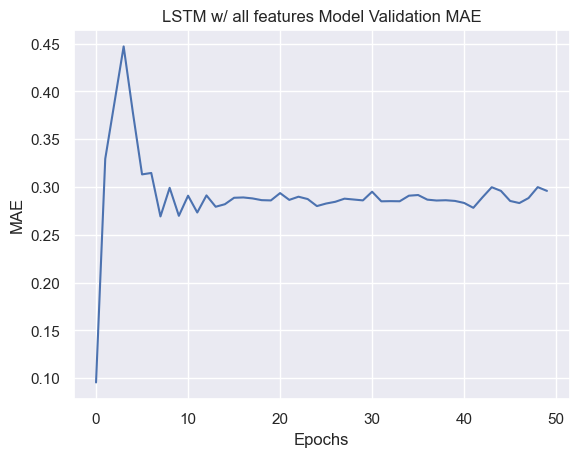

In [39]:
tf.random.set_seed(0)

lstm_model_all_features = tf.keras.Sequential()

lstm_model_all_features.add(tf.keras.layers.LSTM(32, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])))

# Output layer
lstm_model_all_features.add(tf.keras.layers.Dense(1))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

lstm_model_all_features.compile(optimizer=optimizer, loss='mae', metrics=['mae', 'mse'])

lstm_all_features_history = lstm_model_all_features.fit(
        X_train, y_train,
        validation_data = (X_val, y_val),
        epochs=50,
        batch_size=64,
        verbose=1,
        callbacks=[early_stopping])

lstm_train_loss = lstm_all_features_history.history['loss'][-1]
lstm_val_loss, lstm_val_mae, lstm_val_mse = lstm_model_all_features.evaluate(X_val, y_val)
lstm_test_loss, lstm_test_mae, lstm_test_mse = lstm_model_all_features.evaluate(X_test, y_test)
print(f"Training Loss (MAE): {lstm_train_loss}")
print(f"Validation Loss (MAE): {lstm_val_loss}, Validation MAE: {lstm_val_mae}, Validation MSE: {lstm_val_mse}")
print(f"Test Loss (MAE): {lstm_test_loss}, Test MAE: {lstm_test_mae}, Test MSE: {lstm_test_mse}")

plot_model_mae(lstm_all_features_history, 'LSTM w/ all features')

In [40]:
lstm_model_all_features.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,069 (78.40 KB)

 Trainable params: 6,689 (26.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,380 (52.27 KB)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


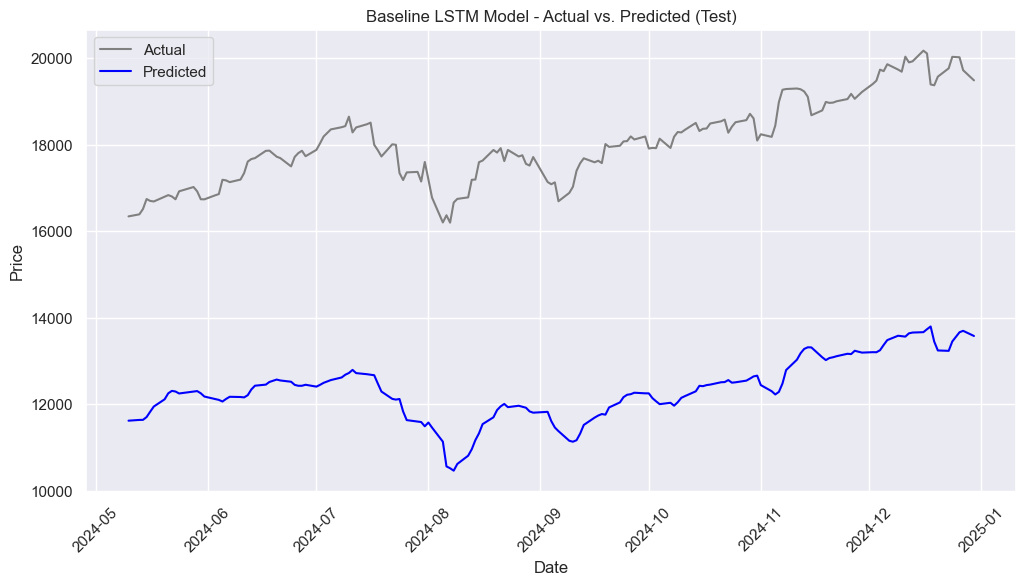

In [41]:
plot_predictions(test_dates, output_scaler.inverse_transform(y_test), output_scaler.inverse_transform(lstm_model_all_features.predict(X_test)), "Baseline LSTM Model - Actual vs. Predicted (Test)")

In [42]:
mae_mse_report(y_val, lstm_model_all_features.predict(X_val), output_scaler, label='Baseline LSTM - All Features - Validation')

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Baseline LSTM - All Features - Validation MAE: $2,721.96 (19.87% within range)
Baseline LSTM - All Features - Validation MSE: $7,650,942.91


In [43]:
mae_mse_report(y_test, lstm_model_all_features.predict(X_test), output_scaler, label='Baseline LSTM - All Features - Test')

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Baseline LSTM - All Features - Test MAE: $5,730.29 (31.75% within range)
Baseline LSTM - All Features - Test MSE: $33,094,224.96


## Hyperparmeter Tuning - yfinance + FRED + engineered features - using MSE as loss

Trial 50 Complete [00h 00m 30s]
val_loss: 0.02280646050348878

Best val_loss So Far: 0.00500313922141989
Total elapsed time: 01h 21m 56s
Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 0.9680 - mae: 0.7313 - val_loss: 0.0151 - val_mae: 0.1130
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0269 - mae: 0.1323 - val_loss: 0.0047 - val_mae: 0.0586
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0181 - mae: 0.1115 - val_loss: 0.0837 - val_mae: 0.2852
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0072 - mae: 0.0693 - val_loss: 0.1072 - val_mae: 0.3243
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0038 - mae: 0.0486 - val_loss: 0.0900 - val_mae: 0.2969
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0031 - mae: 0.0442 - val_loss: 0.0589 - val_mae: 0.2392
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0026 - mae: 0.0394 - val_loss: 0.0400 - val_mae: 0.1959
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━

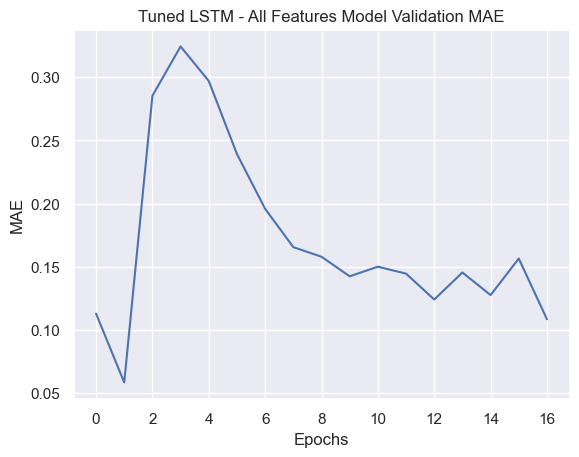

In [44]:
# Define the model builder function
def build_model(hp):

    # Create a new sequential model where layers are stacked linearly
    model = keras.Sequential()
    
    # Define a hyperparmeter for number of LSTM layers (1 to 3) to include in the model
    num_lstm_layers = hp.Int('num_lstm_layers', min_value=1, max_value=3, step=1)
    
    for i in range(num_lstm_layers):
        model.add(layers.LSTM(
            # number of units(neurons)
            units=hp.Int(f'lstm_units_{i}', min_value=32, max_value=256, step=32),
            activation='tanh',
            return_sequences=(i < num_lstm_layers - 1)  # Only last LSTM layer should return False
        ))
        model.add(layers.Dropout(hp.Float(f'dropout_rate_{i}', min_value=0.1, max_value=0.5, step=0.1)))

    # A dense output layer with 1 neuron to predict a single continuous value
    model.add(layers.Dense(1, activation='linear'))
    
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', values=[1e-4, 5e-4, 1e-3, 5e-3])
        ),
        loss='mse',
        metrics=['mae']
    )
    
    return model

# Initialize tuner
tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective("val_loss", direction="min"),
    # try up to 50 different combinations
    max_trials=50, 
    # each trial is trained 3 times for more reliable performance estimates
    executions_per_trial=3,
    directory='lstm_tuning_0411',
    project_name='financial_time_series_allfeatures'
)

# Start hyperparameter tuning
# Early stopping if validation loss doesn't improve for 10 epochs
tuner.search(X_train, y_train, epochs=100, validation_data=(X_val, y_val), batch_size=64, 
             callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)])

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Build the best model
best_model = tuner.hypermodel.build(best_hps)

# Train the best model
history = best_model.fit(X_train, y_train, epochs=200, validation_data=(X_val, y_val), batch_size=64, 
                         callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])

# Evaluate the model on validation and test set
train_mae = history.history['loss'][-1]
print(f'Training MAE: {train_mae:.6f}')
val_mse, val_mae = best_model.evaluate(X_val, y_val)
print(f'Validation MSE: {val_mse:.6f}, Validation MAE: {val_mae:.6f}')
test_mse, test_mae = best_model.evaluate(X_test, y_test)
print(f'Test MSE: {test_mse:.6f}, Test MAE: {test_mae:.6f}')

plot_model_mae(history, 'Tuned LSTM - All Features')

In [45]:
mae_mse_report(y_val, best_model.predict(X_val), output_scaler, label='Tuned LSTM - All Features - Validation')

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Tuned LSTM - All Features - Validation MAE: $538.80 (3.93% within range)
Tuned LSTM - All Features - Validation MSE: $396,261.31


In [46]:
mae_mse_report(y_test, best_model.predict(X_test), output_scaler, label='Tuned LSTM - All Features - Test')

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Tuned LSTM - All Features - Test MAE: $3,328.90 (18.44% within range)
Tuned LSTM - All Features - Test MSE: $11,506,530.08


In [47]:
best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 224)            │       218,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 656,549 (2.50 MB)

 Trainable params: 218,849 (854.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 437,700 (1.67 MB)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


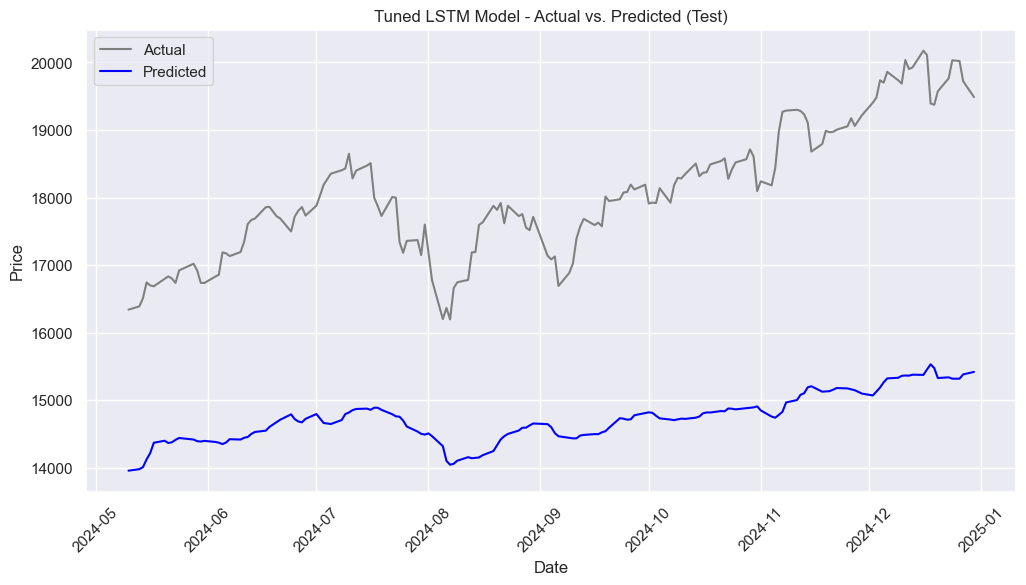

In [48]:
plot_predictions(test_dates, output_scaler.inverse_transform(y_test), output_scaler.inverse_transform(best_model.predict(X_test)), "Tuned LSTM Model - Actual vs. Predicted (Test)")

# Hyperparameter Analysis

## Summary by Trial

In [49]:
trial_summaries = []

for trial in tuner.oracle.trials.values():
    hp_values = trial.hyperparameters.values.copy()
    hp_values['score'] = trial.score
    hp_values['trial_id'] = trial.trial_id
    trial_summaries.append(hp_values)

results_df = pd.DataFrame(trial_summaries)
results_df = results_df.sort_values(by='score').reset_index(drop=True)

results_df.head(50)

,num_lstm_layers,lstm_units_0,dropout_rate_0,learning_rate,score,trial_id,lstm_units_1,dropout_rate_1,lstm_units_2,dropout_rate_2
0,1,224,0.1,0.0050,0.005003,34,32.0,0.4,32.0,0.3
1,1,192,0.5,0.0010,0.005894,05,96.0,0.1,224.0,0.3
2,1,160,0.2,0.0050,0.006762,24,256.0,0.2,64.0,0.3
3,2,128,0.3,0.0001,0.006888,11,224.0,0.1,128.0,0.3
4,3,192,0.3,0.0050,0.007204,18,224.0,0.1,64.0,0.1
5,2,224,0.5,0.0050,0.007454,41,256.0,0.1,256.0,0.2
6,3,160,0.1,0.0050,0.007749,48,256.0,0.2,128.0,0.1
7,3,224,0.3,0.0050,0.008542,01,32.0,0.1,32.0,0.1
8,3,96,0.3,0.0005,0.008804,43,32.0,0.3,64.0,0.3
9,2,192,0.1,0.0001,0.008885,38,192.0,0.4,128.0,0.2


In [55]:
best_trial_id = results_df.loc[0, 'trial_id']
best_score = results_df.loc[0, 'score']
print(f"Best trial: {best_trial_id} with score: {best_score:.4f}")

Best trial: 34 with score: 0.0050


## LSTM Layers

/var/folders/89/572hqr1x26j5sf69pfl_2fd80000gn/T/ipykernel_3428/2966608722.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='num_lstm_layers', y='score', data=results_df, palette='Set2')


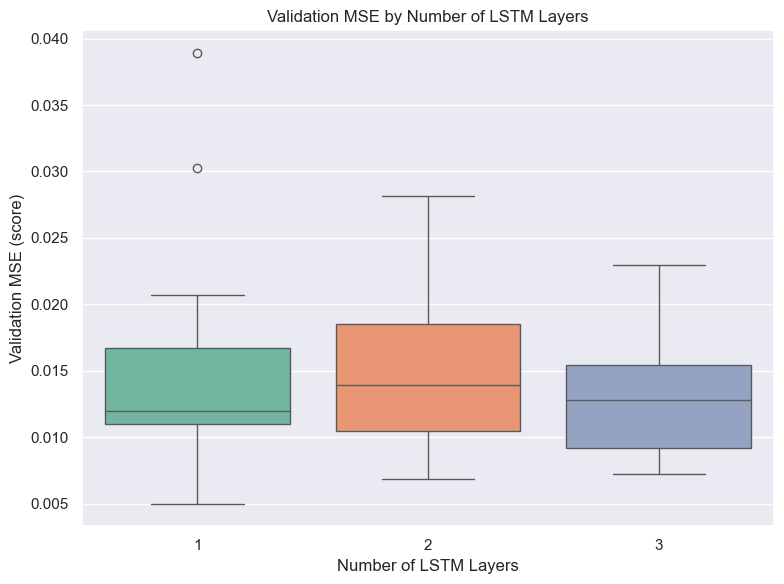

In [50]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='num_lstm_layers', y='score', data=results_df, palette='Set2')
plt.xlabel('Number of LSTM Layers')
plt.ylabel('Validation MSE (score)')
plt.title('Validation MSE by Number of LSTM Layers')
plt.grid(True, axis='y')
plt.tight_layout();

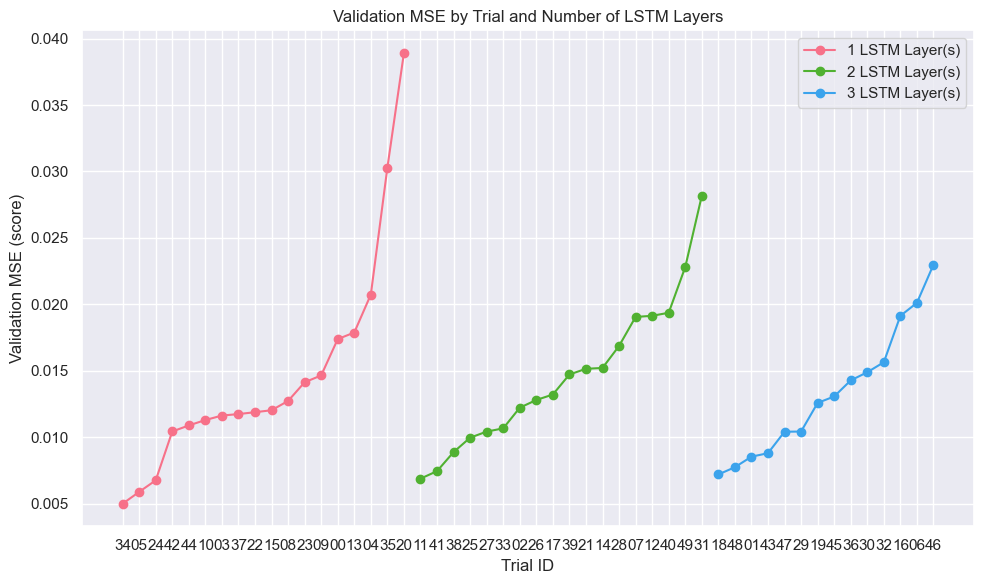

In [51]:
# Plotting trial score by trial ID, grouped by num_lstm_layers
palette = sns.color_palette("husl", n_colors=3)

plt.figure(figsize=(10, 6))

for i, num_layers in enumerate(sorted(results_df['num_lstm_layers'].unique())):
    subset = results_df[results_df['num_lstm_layers'] == num_layers]
    plt.plot(subset['trial_id'], subset['score'], 
             marker='o', label=f'{num_layers} LSTM Layer(s)', color=palette[i])

plt.xlabel('Trial ID')
plt.ylabel('Validation MSE (score)')
plt.title('Validation MSE by Trial and Number of LSTM Layers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Neurons

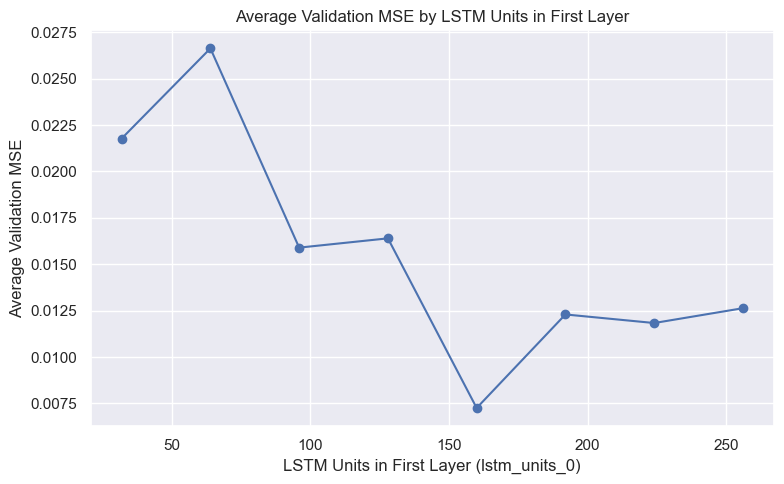

In [52]:
# Group by lstm_units_0 and calculate the average score
avg_scores = results_df.groupby('lstm_units_0')['score'].mean().reset_index()

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(avg_scores['lstm_units_0'], avg_scores['score'], marker='o', linestyle='-')
plt.xlabel('LSTM Units in First Layer (lstm_units_0)')
plt.ylabel('Average Validation MSE')
plt.title('Average Validation MSE by LSTM Units in First Layer')
plt.grid(True)
plt.tight_layout()
plt.show()

## Dropout Rate

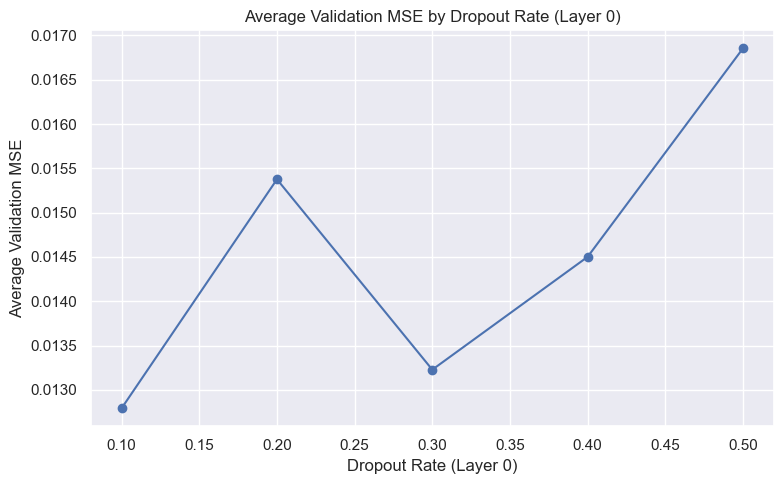

In [53]:

# Group by dropout_rate_0
avg_dropout_scores = results_df.groupby('dropout_rate_0')['score'].mean().reset_index()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(avg_dropout_scores['dropout_rate_0'], avg_dropout_scores['score'], marker='o')
plt.xlabel('Dropout Rate (Layer 0)')
plt.ylabel('Average Validation MSE')
plt.title('Average Validation MSE by Dropout Rate (Layer 0)')
plt.grid(True)
plt.tight_layout()
plt.show()

## Learning Rate

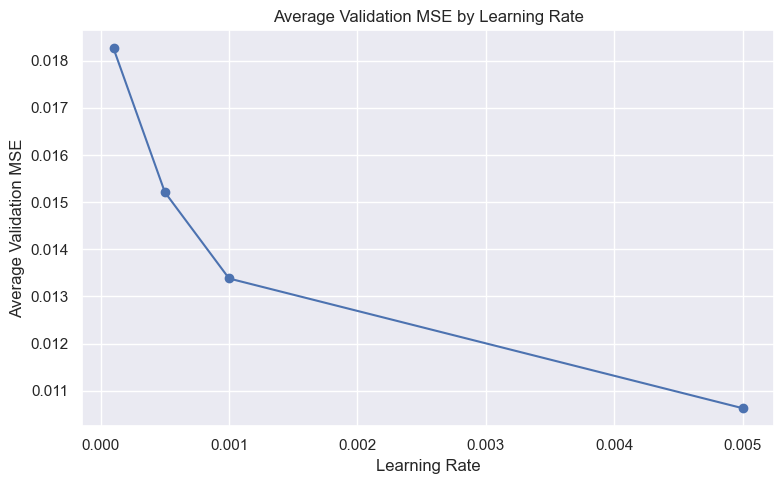

In [54]:
# Group by learning_rate
avg_lr_scores = results_df.groupby('learning_rate')['score'].mean().reset_index()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(avg_lr_scores['learning_rate'], avg_lr_scores['score'], marker='o')
plt.xlabel('Learning Rate')
plt.ylabel('Average Validation MSE')
plt.title('Average Validation MSE by Learning Rate')
plt.grid(True)
plt.tight_layout()
plt.show()